# 11 · Final Hybrid Forecasting Strategy

## tl;dr

Validation 选择的天气组合是**仅预测降水**；锁定路由为 1h Forecasted Direct、3h Forecasted Recursive、6–168h Weekly Seasonal Naive。Final Test 每个 horizon 有 238 个共同起报点。Hybrid 汇总 MAE **1,125.53 rides/hour**，比 Validation 锁定的最佳单模型 Weekly Naive 低 **12.37%**，但比 No-weather Direct 只低 **0.55%**；Hybrid 的 RMSE/P90 还略高于后者。

因此可进入**带监控的 shadow 工程验证**，不宜直接上线生产。预测天气在 Final Test 的 1h/3h 均不如对应的无天气方法，尚未证明值得作为生产依赖；温度也不是本次 Validation 最有价值的可预测天气变量。Oracle Recursive MAE 为 833.04，说明真实未来天气仍有显著研究价值，但它不可部署。

**研究限制**：11 的 Test 未参与本次选择，但该区间曾由 10 评估，不是项目历史上从未见过的盲测；Training 止于 8 月，需求模型对 9–12 月有季节外推限制。结论还需未来新时间段验证。


## Context & Methods · 时间顺序与选择协议

延续 07–10 的小时级数据、Direct/Recursive HGB、天气前向折 OOF、Weekly Naive 与 8 个 horizon。设 first future hour 为 t，forecast origin 为 t−1h，目标为 t+(h−1)h。

1. Training：2024-01-01 00:00 至 2024-08-31 23:00。仅此区间训练需求与天气模型。
2. Validation：2024-09-01 00:00 至 2024-10-19 17:00。先比较 5 种天气输入，再用最佳非空天气组合与无天气、Weekly 一起选逐 horizon 路由；同时锁定一个全 horizon 最佳单模型作稳定性参照。
3. Final Holdout Test：2024-10-19 18:00 至 2024-12-31 23:00。只在锁定规则后评估一次；不回头改组合、模型、参数或路由。

天气输入选择分数是 8 个 horizon、所有验证起报点上 Direct MAE 和 Recursive MAE 的等权均值。No-weather 参与对照；若其分数更低，仍保留验证期最佳的非空天气组合供路由比较。除指定组合，还预先加入 humidity-only、precipitation-only、wind-only、无温度三变量组合，以检查“温度最有价值”这一假设。并列按预先声明的候选顺序打破。Validation 的两次选择共用同一窗口，因此其获胜 MAE 可能乐观；独立 Final Test 用来检验。

**关键假设**：已有观测天气可用到起报点，未来实际天气不可用；日历在起报点已知；原始小时序列连续，DST 两个特殊小时沿用 07–10 的目标样本排除规则。未来天气模型使用该完整小时轴中截至 origin 的历史天气，缺失的春季小时仅用之前天气前向填充。

**项目层面的盲测限制**：本 Final Test 区间与 10 已报告的旧测试区间重叠。11 严格只用新的 Validation 锁定所有选择，且没有调用 10 的测试分数，但它不能充当从未被项目研究者观察过的全新盲测。任何部署判定须再用之后新增的时间数据做 shadow 验证。

**季节外推限制**：需求日历的月份 dummy 只保留 Training 出现过的月份；训练截至 8 月，9–12 月均没有独立月份 dummy。此设定沿用 07–10 的实现，不因 Final Test 结果而改动。


## Data · 来源、切分与配对样本

输入为 data/processed/bikeflow_2024.csv。先在连续小时轴生成 lag/rolling，再排除 2024-03-10 02:00 与 2024-11-03 01:00 作为建模目标，与 07–10 的口径一致。目标需求及真实天气都不会进入候选模型的未来特征。

In [1]:
from pathlib import Path
from types import MappingProxyType
import hashlib
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.ensemble import HistGradientBoostingRegressor

HORIZONS = (1, 3, 6, 12, 24, 48, 72, 168)
WEATHER_COLUMNS = (
    "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"
)
DEMAND_COLUMNS = ("lag_1", "lag_24", "lag_168", "rolling_mean_3", "rolling_mean_6")
WEATHER_LAGS = (1, 3, 6, 24, 48, 168)
WEATHER_ROLLS = (3, 6, 24)
DEMAND_PARAMETERS = dict(
    max_iter=240, learning_rate=0.07, max_leaf_nodes=31,
    min_samples_leaf=25, l2_regularization=0.1,
    early_stopping=False, random_state=42,
)
WEATHER_PARAMETERS = dict(
    max_iter=100, learning_rate=0.07, max_leaf_nodes=15,
    min_samples_leaf=30, l2_regularization=0.1,
    early_stopping=False, random_state=42,
)
TRAIN_END = pd.Timestamp("2024-08-31 23:00")
VALIDATION_START = TRAIN_END + pd.Timedelta(hours=1)
TEST_START = pd.Timestamp("2024-10-19 18:00")
VALIDATION_END = TEST_START - pd.Timedelta(hours=1)
TEST_END = pd.Timestamp("2024-12-31 23:00")
VARIANTS = {
    "No-weather": (),
    "Temperature": ("temperature_2m",),
    "Temperature + humidity": ("temperature_2m", "relative_humidity_2m"),
    "Temperature + wind": ("temperature_2m", "wind_speed_10m"),
    "All four": WEATHER_COLUMNS,
    "Humidity": ("relative_humidity_2m",),
    "Precipitation": ("precipitation",),
    "Wind": ("wind_speed_10m",),
    "Humidity + precipitation + wind": (
        "relative_humidity_2m", "precipitation", "wind_speed_10m"
    ),
}
PREDICTED_COLUMNS = tuple(f"{name}_pred" for name in WEATHER_COLUMNS)
plt.rcParams.update({
    "figure.figsize": (11, 5), "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "savefig.dpi": 130,
})
project_root = Path.cwd()
if not (project_root / "data" / "processed" / "bikeflow_2024.csv").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "processed" / "bikeflow_2024.csv"
data = pd.read_csv(data_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
assert len(data) == 8784 and data["timestamp"].is_unique
assert data["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()
assert data["ride_count"].notna().all()
assert set(WEATHER_COLUMNS).issubset(data.columns)
for lag in (1, 24, 168):
    data[f"lag_{lag}"] = data["ride_count"].shift(lag)
for window in (3, 6):
    data[f"rolling_mean_{window}"] = data["ride_count"].shift(1).rolling(window).mean()
spring_gap = pd.Timestamp("2024-03-10 02:00")
fall_repeat = pd.Timestamp("2024-11-03 01:00")
model_data = data.loc[~data["timestamp"].isin([spring_gap, fall_repeat])].copy().reset_index(drop=True)
assert len(model_data) == 8782
observed_demand = data.set_index("timestamp")["ride_count"]
observed_weather_raw = data.set_index("timestamp")[list(WEATHER_COLUMNS)]
observed_weather = observed_weather_raw.ffill()
assert observed_weather.notna().all(axis=None)
assert observed_weather_raw.loc[spring_gap].isna().all()
print("数据来源：", data_path)
print("原始连续小时：", len(data), "；可作为目标的小时：", len(model_data))

数据来源： C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
原始连续小时： 8784 ；可作为目标的小时： 8782


In [2]:
split_rows = []
for name, start, end in (
    ("Training", data["timestamp"].min(), TRAIN_END),
    ("Validation", VALIDATION_START, VALIDATION_END),
    ("Final Holdout Test", TEST_START, TEST_END),
):
    frame = model_data.loc[model_data["timestamp"].between(start, end)]
    split_rows.append({
        "Window": name, "First timestamp": frame["timestamp"].min(),
        "Last timestamp": frame["timestamp"].max(), "Eligible target hours": len(frame),
    })
split_table = pd.DataFrame(split_rows)
assert split_table["Eligible target hours"].sum() == len(model_data)
assert TRAIN_END < VALIDATION_START <= VALIDATION_END < TEST_START <= TEST_END
display(split_table)
print("训练标签严格早于 Validation；验证标签严格早于 Final Test。")

训练标签严格早于 Validation；验证标签严格早于 Final Test。


,Window,First timestamp,Last timestamp,Eligible target hours
0,Training,2024-01-01 00:00:00,2024-08-31 23:00:00,5855
1,Validation,2024-09-01 00:00:00,2024-10-19 17:00:00,1170
2,Final Holdout Test,2024-10-19 18:00:00,2024-12-31 23:00:00,1757


### 固定信息边界与共同起报点

日历特征只从目标时间推导。需求 lag/rolling 都截至 origin；Direct 的训练标签在目标时间。Validation 与 Test 预先固定每日 00:00、07:00、12:00、18:00 四个 first-future hour，只保留全部 168 小时目标均处于对应窗口的起报点。这使每种方法、每个 horizon 拥有完全相同的 origins 与 targets，也让各 horizon 的 Peak/Off-peak 比较有样本。

In [3]:
timestamps = pd.DatetimeIndex(model_data["timestamp"])
calendar_parts = pd.DataFrame({
    "target_hour": pd.Categorical(timestamps.hour, categories=range(24)),
    "target_day_of_week": pd.Categorical(timestamps.dayofweek, categories=range(7)),
    "target_month": pd.Categorical(timestamps.month, categories=range(1, 13)),
})
calendar_full = pd.get_dummies(calendar_parts, drop_first=True, dtype=int)
train_calendar_mask = timestamps <= TRAIN_END
calendar_columns = calendar_full.columns[calendar_full.loc[train_calendar_mask].any(axis=0)].tolist()
calendar_target = calendar_full[calendar_columns].copy()
calendar_target.index = timestamps
origin_demand = model_data[list(DEMAND_COLUMNS)].copy()
origin_demand.index = timestamps
weather_target = model_data[list(WEATHER_COLUMNS)].copy()
weather_target.index = timestamps

valid_lags = model_data[list(DEMAND_COLUMNS)].notna().all(axis=1)
candidate_train = pd.DatetimeIndex(model_data.loc[valid_lags & (model_data["timestamp"] <= TRAIN_END), "timestamp"])
training_specs = {}
for horizon in HORIZONS:
    targets = candidate_train + pd.Timedelta(hours=horizon - 1)
    keep = targets.isin(timestamps) & (targets <= TRAIN_END)
    training_specs[horizon] = (candidate_train[keep], targets[keep])
    assert len(training_specs[horizon][0]) > 4000

def common_origins(first_candidate, window_start, window_end):
    candidates = pd.date_range(first_candidate, window_end - pd.Timedelta(hours=167), freq="h")
    candidates = candidates[candidates.hour.isin((0, 7, 12, 18))]
    eligible = set(model_data.loc[
        model_data["timestamp"].between(window_start, window_end) & valid_lags, "timestamp"
    ])
    starts = pd.DatetimeIndex([
        start for start in candidates
        if start >= window_start
        and all(target in eligible for target in pd.date_range(start, periods=168, freq="h"))
    ])
    assert len(starts) > 0
    return starts

validation_starts = common_origins(VALIDATION_START, VALIDATION_START, VALIDATION_END)
assert (validation_starts >= VALIDATION_START).all()
assert (validation_starts + pd.Timedelta(hours=167) <= VALIDATION_END).all()
display(pd.DataFrame({
    "Horizon (h)": HORIZONS,
    "Training pairs": [len(training_specs[h][0]) for h in HORIZONS],
    "Validation paired origins": len(validation_starts),
}))
print("Validation first/last first-future hour:", validation_starts.min(), validation_starts.max())

Validation first/last first-future hour: 2024-09-01 00:00:00 2024-10-12 18:00:00


,Horizon (h),Training pairs,Validation paired origins
0,1,5687,168
1,3,5684,168
2,6,5681,168
3,12,5675,168
4,24,5663,168
5,48,5639,168
6,72,5615,168
7,168,5519,168


## Weather forecasting · 历史天气到目标天气

沿用 10 的 Direct HGB 天气模型：每个 horizon × 变量各一个模型；特征为目标日历和截至 origin 的天气 lag/rolling。训练需求模型所需的天气预测采用按时间顺序的前向折 OOF：折的天气训练标签严格早于该折开始；早期 warm-up 使用上一周同小时天气，它对 h≤168 同样不越过 origin。Validation/Test 天气预测来自仅在 Training 训练的固定模型。

In [4]:
weather_history = pd.DataFrame(index=observed_weather.index)
for variable in WEATHER_COLUMNS:
    prior = observed_weather[variable].shift(1)
    for lag in WEATHER_LAGS:
        weather_history[f"{variable}_lag_{lag}"] = observed_weather[variable].shift(lag)
    for window in WEATHER_ROLLS:
        weather_history[f"{variable}_roll_mean_{window}"] = prior.rolling(window).mean()
        weather_history[f"{variable}_roll_std_{window}"] = prior.rolling(window).std(ddof=0)
weather_calendar = calendar_target.copy()
weather_calendar["weather_target_weekend"] = (timestamps.dayofweek >= 5).astype(int)
weather_calendar["weather_target_hour_sin"] = np.sin(2 * np.pi * timestamps.hour / 24)
weather_calendar["weather_target_hour_cos"] = np.cos(2 * np.pi * timestamps.hour / 24)
weather_calendar["weather_target_doy_sin"] = np.sin(2 * np.pi * timestamps.dayofyear / 366)
weather_calendar["weather_target_doy_cos"] = np.cos(2 * np.pi * timestamps.dayofyear / 366)
weather_input_columns = list(weather_calendar.columns) + list(weather_history.columns)

def make_weather_matrix(starts, targets):
    starts, targets = pd.DatetimeIndex(starts), pd.DatetimeIndex(targets)
    assert len(starts) == len(targets)
    assert (targets > starts - pd.Timedelta(hours=1)).all()
    parts = [
        weather_calendar.loc[targets].reset_index(drop=True),
        weather_history.loc[starts].reset_index(drop=True),
    ]
    matrix = pd.concat(parts, axis=1)[weather_input_columns]
    assert matrix.notna().all(axis=None)
    assert set(matrix.columns).isdisjoint(WEATHER_COLUMNS)
    return matrix

def weather_weekly_warmup(starts, targets):
    starts, targets = pd.DatetimeIndex(starts), pd.DatetimeIndex(targets)
    source = targets - pd.Timedelta(hours=168)
    assert (source <= starts - pd.Timedelta(hours=1)).all()
    result = observed_weather.reindex(source).reset_index(drop=True)
    assert result.notna().all(axis=None)
    return result

for horizon in HORIZONS:
    starts, targets = training_specs[horizon]
    matrix = make_weather_matrix(starts, targets)
    assert (starts <= TRAIN_END).all() and (targets <= TRAIN_END).all()
    for lag in WEATHER_LAGS:
        source = starts - pd.Timedelta(hours=lag)
        assert (source <= starts - pd.Timedelta(hours=1)).all()
        for variable in WEATHER_COLUMNS:
            np.testing.assert_allclose(
                matrix[f"{variable}_lag_{lag}"].to_numpy(),
                observed_weather[variable].reindex(source).to_numpy(),
            )
print("Weather feature timing audit: PASS；", len(weather_input_columns), "weather model inputs")

Weather feature timing audit: PASS； 89 weather model inputs


In [5]:
OOF_CUTOFFS = (pd.Timestamp("2024-04-01 00:00"), pd.Timestamp("2024-07-01 00:00"))
oof_weather = {}
oof_audit_rows = []
for horizon in HORIZONS:
    starts, targets = training_specs[horizon]
    forecast = weather_weekly_warmup(starts, targets).to_numpy(copy=True)
    source_type = np.full(len(starts), "prior-week warm-up", dtype=object)
    for fold_start, fold_end in zip(OOF_CUTOFFS, (*OOF_CUTOFFS[1:], VALIDATION_START)):
        fit = targets < fold_start
        predict = (starts >= fold_start) & (starts < fold_end)
        if not predict.any():
            continue
        assert fit.any() and (targets[fit] < fold_start).all()
        assert (starts[predict] >= fold_start).all()
        fit_x = make_weather_matrix(starts[fit], targets[fit])
        predict_x = make_weather_matrix(starts[predict], targets[predict])
        for index, variable in enumerate(WEATHER_COLUMNS):
            fold_model = HistGradientBoostingRegressor(**WEATHER_PARAMETERS)
            fold_model.fit(fit_x, weather_target.loc[targets[fit], variable].to_numpy())
            forecast[predict, index] = fold_model.predict(predict_x)
        source_type[predict] = f"HGB labels before {fold_start.date()}"
        oof_audit_rows.append({
            "Horizon": horizon, "Fold start": fold_start,
            "Last fit target": targets[fit].max(),
            "First forecast origin": (starts[predict] - pd.Timedelta(hours=1)).min(),
            "Forecast rows": int(predict.sum()),
        })
    assert np.isfinite(forecast).all()
    assert (starts[source_type == "prior-week warm-up"] < OOF_CUTOFFS[0]).all()
    oof_weather[horizon] = pd.DataFrame(forecast, columns=PREDICTED_COLUMNS)
    print(f"Forward OOF weather: h={horizon:>3}h, {len(starts):,} training pairs")
oof_audit = pd.DataFrame(oof_audit_rows)
assert (oof_audit["Last fit target"] < oof_audit["Fold start"]).all()
assert (oof_audit["Last fit target"] <= oof_audit["First forecast origin"]).all()
display(oof_audit)

Forward OOF weather: h=  1h, 5,687 training pairs
Forward OOF weather: h=  3h, 5,684 training pairs
Forward OOF weather: h=  6h, 5,681 training pairs
Forward OOF weather: h= 12h, 5,675 training pairs
Forward OOF weather: h= 24h, 5,663 training pairs
Forward OOF weather: h= 48h, 5,639 training pairs
Forward OOF weather: h= 72h, 5,615 training pairs
Forward OOF weather: h=168h, 5,519 training pairs


,Horizon,Fold start,Last fit target,First forecast origin,Forecast rows
0,1,2024-04-01,2024-03-31 23:00:00,2024-03-31 23:00:00,2184
1,1,2024-07-01,2024-06-30 23:00:00,2024-06-30 23:00:00,1488
2,3,2024-04-01,2024-03-31 23:00:00,2024-03-31 23:00:00,2184
3,3,2024-07-01,2024-06-30 23:00:00,2024-06-30 23:00:00,1486
4,6,2024-04-01,2024-03-31 23:00:00,2024-03-31 23:00:00,2184
5,6,2024-07-01,2024-06-30 23:00:00,2024-06-30 23:00:00,1483
6,12,2024-04-01,2024-03-31 23:00:00,2024-03-31 23:00:00,2184
7,12,2024-07-01,2024-06-30 23:00:00,2024-06-30 23:00:00,1477
8,24,2024-04-01,2024-03-31 23:00:00,2024-03-31 23:00:00,2184
9,24,2024-07-01,2024-06-30 23:00:00,2024-06-30 23:00:00,1465


In [6]:
weather_models = {}
for horizon in HORIZONS:
    starts, targets = training_specs[horizon]
    matrix = make_weather_matrix(starts, targets)
    weather_models[horizon] = {}
    for variable in WEATHER_COLUMNS:
        fitted = HistGradientBoostingRegressor(**WEATHER_PARAMETERS)
        fitted.fit(matrix, weather_target.loc[targets, variable].to_numpy())
        weather_models[horizon][variable] = fitted
    print(f"Fixed Training-only weather models: h={horizon:>3}h")

def predict_weather_direct(starts, targets, horizon):
    starts, targets = pd.DatetimeIndex(starts), pd.DatetimeIndex(targets)
    assert (targets == starts + pd.Timedelta(hours=horizon - 1)).all()
    matrix = make_weather_matrix(starts, targets)
    result = np.column_stack([
        weather_models[horizon][variable].predict(matrix) for variable in WEATHER_COLUMNS
    ])
    assert np.isfinite(result).all()
    return result

def predict_weather_path(starts):
    starts = pd.DatetimeIndex(starts)
    origins = starts - pd.Timedelta(hours=1)
    prediction = np.full((len(starts), 168, len(WEATHER_COLUMNS)), np.nan)
    anchors = {
        lead: predict_weather_direct(
            starts, starts + pd.Timedelta(hours=lead - 1), lead
        ) for lead in HORIZONS
    }
    def previous(variable, variable_index, targets, step, lag):
        if step <= lag:
            source = targets - pd.Timedelta(hours=lag)
            assert (source <= origins).all()
            return observed_weather[variable].reindex(source).to_numpy()
        return prediction[:, step - lag - 1, variable_index]
    for step in range(1, 169):
        if step in anchors:
            prediction[:, step - 1, :] = anchors[step]
            continue
        targets = starts + pd.Timedelta(hours=step - 1)
        row = weather_calendar.loc[targets].reset_index(drop=True).copy()
        for variable_index, variable in enumerate(WEATHER_COLUMNS):
            for lag in WEATHER_LAGS:
                row[f"{variable}_lag_{lag}"] = previous(variable, variable_index, targets, step, lag)
            for window in WEATHER_ROLLS:
                prior = np.column_stack([
                    previous(variable, variable_index, targets, step, lag)
                    for lag in range(1, window + 1)
                ])
                row[f"{variable}_roll_mean_{window}"] = prior.mean(axis=1)
                row[f"{variable}_roll_std_{window}"] = prior.std(axis=1, ddof=0)
        matrix = row[weather_input_columns]
        assert matrix.notna().all(axis=None)
        prediction[:, step - 1, :] = np.column_stack([
            weather_models[1][variable].predict(matrix) for variable in WEATHER_COLUMNS
        ])
    assert np.isfinite(prediction).all()
    for lead, values in anchors.items():
        np.testing.assert_allclose(prediction[:, lead - 1, :], values)
    return prediction

Fixed Training-only weather models: h=  1h
Fixed Training-only weather models: h=  3h
Fixed Training-only weather models: h=  6h
Fixed Training-only weather models: h= 12h
Fixed Training-only weather models: h= 24h
Fixed Training-only weather models: h= 48h
Fixed Training-only weather models: h= 72h
Fixed Training-only weather models: h=168h


## Demand models · 共用 HGB 参数、不同天气输入

九种输入共享目标日历与起报点可见需求 lag/rolling。Forecasted-weather 仅使用带 _pred 后缀的模型预测天气；No-weather 完全不带天气。Direct 每个 horizon 训练一个模型；Recursive 只用 h=1 模型沿预测路径回填未来需求。

In [7]:
def variant_columns(variant):
    return (
        calendar_columns
        + [f"{variable}_pred" for variable in VARIANTS[variant]]
        + list(DEMAND_COLUMNS)
    )

def make_demand_matrix(variant, starts, targets, predicted_weather=None):
    starts, targets = pd.DatetimeIndex(starts), pd.DatetimeIndex(targets)
    assert len(starts) == len(targets)
    assert (targets > starts - pd.Timedelta(hours=1)).all()
    parts = [calendar_target.loc[targets].reset_index(drop=True)]
    if VARIANTS[variant]:
        assert predicted_weather is not None
        assert predicted_weather.shape == (len(starts), len(WEATHER_COLUMNS))
        weather_part = pd.DataFrame(predicted_weather, columns=PREDICTED_COLUMNS)
        parts.append(weather_part[[f"{variable}_pred" for variable in VARIANTS[variant]]])
    parts.append(origin_demand.loc[starts, list(DEMAND_COLUMNS)].reset_index(drop=True))
    matrix = pd.concat(parts, axis=1)[variant_columns(variant)]
    assert matrix.notna().all(axis=None)
    assert set(matrix.columns).isdisjoint(WEATHER_COLUMNS)
    return matrix

demand_models = {}
for variant in VARIANTS:
    demand_models[variant] = {}
    for horizon in HORIZONS:
        starts, targets = training_specs[horizon]
        training_weather = oof_weather[horizon].to_numpy() if VARIANTS[variant] else None
        matrix = make_demand_matrix(variant, starts, targets, training_weather)
        labels = observed_demand.reindex(targets).to_numpy()
        model = HistGradientBoostingRegressor(**DEMAND_PARAMETERS)
        model.fit(matrix, labels)
        demand_models[variant][horizon] = model
    print(f"Training-only demand models: {variant}, {len(HORIZONS)} horizons")

Training-only demand models: No-weather, 8 horizons
Training-only demand models: Temperature, 8 horizons
Training-only demand models: Temperature + humidity, 8 horizons
Training-only demand models: Temperature + wind, 8 horizons
Training-only demand models: All four, 8 horizons
Training-only demand models: Humidity, 8 horizons
Training-only demand models: Precipitation, 8 horizons
Training-only demand models: Wind, 8 horizons
Training-only demand models: Humidity + precipitation + wind, 8 horizons


In [8]:
def recursive_demand_predict(starts, variant, weather_path=None, history=None):
    starts = pd.DatetimeIndex(starts)
    origins = starts - pd.Timedelta(hours=1)
    history = observed_demand if history is None else history
    prediction = np.full((len(starts), 168), np.nan)
    if VARIANTS[variant]:
        assert weather_path is not None
        assert weather_path.shape == (len(starts), 168, len(WEATHER_COLUMNS))
    for step in range(1, 169):
        targets = starts + pd.Timedelta(hours=step - 1)
        row = calendar_target.loc[targets].reset_index(drop=True).copy()
        if VARIANTS[variant]:
            for variable in VARIANTS[variant]:
                variable_index = WEATHER_COLUMNS.index(variable)
                row[f"{variable}_pred"] = weather_path[:, step - 1, variable_index]
        for lag in (1, 24, 168):
            if step <= lag:
                source = targets - pd.Timedelta(hours=lag)
                assert (source <= origins).all()
                row[f"lag_{lag}"] = history.reindex(source).to_numpy()
            else:
                row[f"lag_{lag}"] = prediction[:, step - lag - 1]
        for window in (3, 6):
            prior = []
            for back in range(1, window + 1):
                if step <= back:
                    source = targets - pd.Timedelta(hours=back)
                    assert (source <= origins).all()
                    prior.append(history.reindex(source).to_numpy())
                else:
                    prior.append(prediction[:, step - back - 1])
            row[f"rolling_mean_{window}"] = np.column_stack(prior).mean(axis=1)
        matrix = row[variant_columns(variant)]
        assert matrix.notna().all(axis=None)
        prediction[:, step - 1] = demand_models[variant][1].predict(matrix)
    assert np.isfinite(prediction).all()
    return prediction

def predict_panel(starts, variants, weather_path):
    starts = pd.DatetimeIndex(starts)
    recursive = {
        variant: recursive_demand_predict(starts, variant, weather_path)
        for variant in variants
    }
    parts = []
    for horizon in HORIZONS:
        targets = starts + pd.Timedelta(hours=horizon - 1)
        origins = starts - pd.Timedelta(hours=1)
        weekly_source = targets - pd.Timedelta(hours=168)
        assert (weekly_source <= origins).all()
        row = {
            "Horizon": horizon, "First Future Hour": starts,
            "Forecast Origin": origins, "Target Timestamp": targets,
            "Actual": observed_demand.reindex(targets).to_numpy(),
            "Weekly Seasonal Naive": observed_demand.reindex(weekly_source).to_numpy(),
        }
        for variant in variants:
            model_weather = weather_path[:, horizon - 1, :] if VARIANTS[variant] else None
            matrix = make_demand_matrix(variant, starts, targets, model_weather)
            row[f"Direct::{variant}"] = demand_models[variant][horizon].predict(matrix)
            row[f"Recursive::{variant}"] = recursive[variant][:, horizon - 1]
        parts.append(pd.DataFrame(row))
    panel = pd.concat(parts, ignore_index=True)
    assert not panel.duplicated(["Horizon", "First Future Hour", "Target Timestamp"]).any()
    assert panel.groupby("Horizon").size().eq(len(starts)).all()
    assert np.isfinite(panel.select_dtypes(include="number").to_numpy()).all()
    return panel

def scores(actual, prediction):
    error = np.abs(np.asarray(actual) - np.asarray(prediction))
    worst_count = max(1, math.ceil(len(error) * 0.10))
    return {
        "MAE": error.mean(),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "Median AE": np.median(error),
        "P90 AE": np.quantile(error, 0.9),
        "Worst-decile MAE": np.sort(error)[-worst_count:].mean(),
    }

## Validation · 天气变量选择

只在 Validation 上生成所有九种输入的 Direct 与 Recursive 预测。各输入的比较口径相同。最优非空天气组合只由下表的预注册均值决定；无天气分数作为是否值得保留天气的证据，不能替代对天气候选的选择。以下代码尚未读取任何 Final Test 目标值。

In [9]:
validation_weather_path = predict_weather_path(validation_starts)
validation_panel = predict_panel(validation_starts, list(VARIANTS), validation_weather_path)
assert len(validation_panel) == len(validation_starts) * len(HORIZONS)
assert validation_panel["Target Timestamp"].between(VALIDATION_START, VALIDATION_END).all()
choice_rows = []
for variant in VARIANTS:
    direct_mae = scores(validation_panel["Actual"], validation_panel[f"Direct::{variant}"])["MAE"]
    recursive_mae = scores(validation_panel["Actual"], validation_panel[f"Recursive::{variant}"])["MAE"]
    choice_rows.append({
        "Weather input": variant, "Forecasted variables": ", ".join(VARIANTS[variant]) or "none",
        "Direct MAE": direct_mae, "Recursive MAE": recursive_mae,
        "Selection MAE": (direct_mae + recursive_mae) / 2,
        "Paired points per method": len(validation_panel),
    })
weather_choice_table = pd.DataFrame(choice_rows).sort_values("Selection MAE", kind="stable")
selected_weather_variant = min(
    (name for name in VARIANTS if VARIANTS[name]),
    key=lambda name: choice_rows[list(VARIANTS).index(name)]["Selection MAE"],
)
selected_weather_inputs = VARIANTS[selected_weather_variant]
display(weather_choice_table.round(2))
print("Validation selected nonempty weather combination:", selected_weather_variant, selected_weather_inputs)
print("All-input winner:", weather_choice_table.iloc[0]["Weather input"])

Validation selected nonempty weather combination: Precipitation ('precipitation',)
All-input winner: Precipitation


,Weather input,Forecasted variables,Direct MAE,Recursive MAE,Selection MAE,Paired points per method
6,Precipitation,precipitation,1647.22,1450.05,1548.64,1344
0,No-weather,none,1748.20,1395.63,1571.91,1344
7,Wind,wind_speed_10m,1791.12,1401.21,1596.16,1344
8,Humidity + precipitation + wind,"relative_humidity_2m, precipitation, wind_speed_10m",1659.18,1545.88,1602.53,1344
4,All four,"temperature_2m, relative_humidity_2m, precipitation, wind_speed_10m",1646.86,1673.96,1660.41,1344
2,Temperature + humidity,"temperature_2m, relative_humidity_2m",1712.25,1618.96,1665.61,1344
5,Humidity,relative_humidity_2m,1745.32,1601.12,1673.22,1344
3,Temperature + wind,"temperature_2m, wind_speed_10m",1823.29,1543.68,1683.48,1344
1,Temperature,temperature_2m,1802.88,1587.25,1695.07,1344


## Validation · 逐 horizon 路由并锁定

候选策略顺序预先固定为 Forecasted Direct、Forecasted Recursive、No-weather Direct、No-weather Recursive、Weekly Seasonal Naive。每个 horizon 取同一验证起报点集合上的最低 MAE；精确并列按上述顺序。再用 Validation 所有 horizon 的 pooled MAE 选一个固定最佳单模型，供 Final Test 稳健性对比。锁定摘要哈希记录变量、路由、比较器及时间边界。

In [10]:
CANDIDATE_TO_COLUMN = {
    "Forecasted Direct": f"Direct::{selected_weather_variant}",
    "Forecasted Recursive": f"Recursive::{selected_weather_variant}",
    "No-weather Direct": "Direct::No-weather",
    "No-weather Recursive": "Recursive::No-weather",
    "Weekly Seasonal Naive": "Weekly Seasonal Naive",
}
validation_route_rows = []
for horizon, frame in validation_panel.groupby("Horizon", sort=True):
    for order, (method, column) in enumerate(CANDIDATE_TO_COLUMN.items()):
        validation_route_rows.append({
            "Horizon": horizon, "Strategy": method,
            "MAE": scores(frame["Actual"], frame[column])["MAE"],
            "Tie order": order, "Origins": len(frame),
        })
validation_route_scores = pd.DataFrame(validation_route_rows)
route_table = (
    validation_route_scores.sort_values(["Horizon", "MAE", "Tie order"], kind="stable")
    .groupby("Horizon", as_index=False).first()
    [["Horizon", "Strategy", "MAE", "Origins"]]
    .rename(columns={"Strategy": "Selected strategy", "MAE": "Validation MAE"})
)
route_table["Weather inputs"] = route_table["Selected strategy"].map(
    lambda method: ", ".join(selected_weather_inputs) if method.startswith("Forecasted") else "none"
)
locked_route = MappingProxyType(dict(zip(route_table["Horizon"], route_table["Selected strategy"])))
single_scores = {
    method: scores(validation_panel["Actual"], validation_panel[column])["MAE"]
    for method, column in CANDIDATE_TO_COLUMN.items()
}
locked_single_model = min(CANDIDATE_TO_COLUMN, key=single_scores.get)
lock_payload = {
    "train_end": str(TRAIN_END), "validation_end": str(VALIDATION_END),
    "test_start": str(TEST_START), "weather_variant": selected_weather_variant,
    "weather_inputs": list(selected_weather_inputs),
    "route": {str(h): locked_route[h] for h in HORIZONS},
    "single_model": locked_single_model,
    "demand_parameters": DEMAND_PARAMETERS, "weather_parameters": WEATHER_PARAMETERS,
}
lock_fingerprint = hashlib.sha256(
    json.dumps(lock_payload, sort_keys=True, default=str).encode("utf-8")
).hexdigest()[:16]
assert set(locked_route) == set(HORIZONS)
display(route_table.round(2))
display(pd.DataFrame([
    {"Single strategy": method, "Validation pooled MAE": mae}
    for method, mae in single_scores.items()
]).sort_values("Validation pooled MAE").round(2))
print("LOCKED single-model comparator:", locked_single_model)
print("LOCKED selection fingerprint:", lock_fingerprint)

LOCKED single-model comparator: Weekly Seasonal Naive
LOCKED selection fingerprint: 6f2460944230dfd5


,Horizon,Selected strategy,Validation MAE,Origins,Weather inputs
0,1,Forecasted Direct,909.90,168,precipitation
1,3,Forecasted Recursive,877.88,168,precipitation
2,6,Weekly Seasonal Naive,1022.35,168,none
3,12,Weekly Seasonal Naive,962.14,168,none
4,24,Weekly Seasonal Naive,1015.64,168,none
5,48,Weekly Seasonal Naive,1024.61,168,none
6,72,Weekly Seasonal Naive,1044.11,168,none
7,168,Weekly Seasonal Naive,993.70,168,none


,Single strategy,Validation pooled MAE
4,Weekly Seasonal Naive,1021.78
3,No-weather Recursive,1395.63
1,Forecasted Recursive,1450.05
0,Forecasted Direct,1647.22
2,No-weather Direct,1748.20


## Checks · Leakage audit（Final Test 运行之前）

逐项确认训练标签、OOF 折、日历/天气/需求源时刻，以及 Validation 目标边界。额外将某验证起点之后的真实天气、真实需求大幅扰动：可部署递归预测和 Weekly 预测必须保持完全不变。Oracle 唯一例外是刻意读取未来真实天气，它只在后续单独参考。

In [11]:
audit_rows = []
for horizon in HORIZONS:
    train_starts, train_targets = training_specs[horizon]
    val_targets = validation_starts + pd.Timedelta(hours=horizon - 1)
    assert (train_targets == train_starts + pd.Timedelta(hours=horizon - 1)).all()
    assert (train_targets <= TRAIN_END).all()
    assert (val_targets >= VALIDATION_START).all() and (val_targets <= VALIDATION_END).all()
    assert (train_starts - pd.Timedelta(hours=1) < train_targets).all()
    assert (validation_starts - pd.Timedelta(hours=1) < val_targets).all()
    assert (val_targets - pd.Timedelta(hours=168) <= validation_starts - pd.Timedelta(hours=1)).all()
    for lag in (1, 24, 168):
        assert (train_starts - pd.Timedelta(hours=lag) <= train_starts - pd.Timedelta(hours=1)).all()
        assert (validation_starts - pd.Timedelta(hours=lag) <= validation_starts - pd.Timedelta(hours=1)).all()
    assert set(make_weather_matrix(validation_starts, val_targets).columns).isdisjoint(WEATHER_COLUMNS)
    assert set(make_demand_matrix(
        selected_weather_variant, validation_starts, val_targets,
        validation_weather_path[:, horizon - 1, :]
    ).columns).isdisjoint(WEATHER_COLUMNS)
    audit_rows.append({
        "Horizon": horizon, "Training labels < Validation": "PASS",
        "Validation target within window": "PASS", "History at/before origin": "PASS",
        "Future actual weather absent from candidate X": "PASS",
    })
audit_table = pd.DataFrame(audit_rows)
display(audit_table)

sample_start = validation_starts[0]
sample_origin = sample_start - pd.Timedelta(hours=1)
sample_path = predict_weather_path([sample_start])
original_weather = observed_weather
try:
    observed_weather = original_weather.copy()
    observed_weather.loc[observed_weather.index > sample_origin] += 1_000_000
    corrupted_weather_path = predict_weather_path([sample_start])
finally:
    observed_weather = original_weather
np.testing.assert_array_equal(sample_path, corrupted_weather_path)

future_corrupted_demand = observed_demand.copy()
future_corrupted_demand.loc[future_corrupted_demand.index > sample_origin] += 1_000_000
for variant in ("No-weather", selected_weather_variant):
    normal = recursive_demand_predict([sample_start], variant, sample_path)
    corrupted = recursive_demand_predict(
        [sample_start], variant, sample_path, history=future_corrupted_demand
    )
    np.testing.assert_array_equal(normal, corrupted)
for horizon in HORIZONS:
    target = sample_start + pd.Timedelta(hours=horizon - 1)
    source = target - pd.Timedelta(hours=168)
    assert observed_demand.loc[source] == future_corrupted_demand.loc[source]
assert validation_panel["Forecast Origin"].max() < TEST_START
print("Counterfactual future-weather / future-demand perturbation: PASS")
print("Final Test labels and predictions have not been used in any selection.")

Counterfactual future-weather / future-demand perturbation: PASS
Final Test labels and predictions have not been used in any selection.


,Horizon,Training labels < Validation,Validation target within window,History at/before origin,Future actual weather absent from candidate X
0,1,PASS,PASS,PASS,PASS
1,3,PASS,PASS,PASS,PASS
2,6,PASS,PASS,PASS,PASS
3,12,PASS,PASS,PASS,PASS
4,24,PASS,PASS,PASS,PASS
5,48,PASS,PASS,PASS,PASS
6,72,PASS,PASS,PASS,PASS
7,168,PASS,PASS,PASS,PASS


## Results · Final Holdout Test（规则已锁定）

从此 Cell 才建立 Final Test 起报点、调用预测并读取其目标真实需求。天气和需求模型仍仅由 Training 拟合；Validation 只提供上面的固定路由和天气变量。全部六个可部署方法使用同一 panel，同一行就是同一 horizon、origin 和 target。

In [12]:
assert lock_fingerprint == hashlib.sha256(
    json.dumps(lock_payload, sort_keys=True, default=str).encode("utf-8")
).hexdigest()[:16]
test_starts = common_origins(TEST_START, TEST_START, TEST_END)
test_weather_path = predict_weather_path(test_starts)
test_panel = predict_panel(
    test_starts, ["No-weather", selected_weather_variant], test_weather_path
)
DEPLOYABLE_COLUMNS = {
    "Forecasted Direct": f"Direct::{selected_weather_variant}",
    "Forecasted Recursive": f"Recursive::{selected_weather_variant}",
    "No-weather Direct": "Direct::No-weather",
    "No-weather Recursive": "Recursive::No-weather",
    "Weekly Seasonal Naive": "Weekly Seasonal Naive",
}
for method, column in DEPLOYABLE_COLUMNS.items():
    test_panel[method] = test_panel[column]
test_panel["Final Hybrid Strategy"] = np.nan
for horizon in HORIZONS:
    mask = test_panel["Horizon"].eq(horizon)
    method = locked_route[horizon]
    test_panel.loc[mask, "Final Hybrid Strategy"] = test_panel.loc[mask, method].to_numpy()
EVALUATED_METHODS = list(DEPLOYABLE_COLUMNS) + ["Final Hybrid Strategy"]
assert test_panel["Target Timestamp"].between(TEST_START, TEST_END).all()
assert test_panel.groupby("Horizon").size().eq(len(test_starts)).all()
assert np.isfinite(test_panel[["Actual"] + EVALUATED_METHODS].to_numpy()).all()
assert not test_panel.duplicated(["Horizon", "Forecast Origin", "Target Timestamp"]).any()
assert test_panel["Forecast Origin"].min() >= TEST_START - pd.Timedelta(hours=1)
assert all(
    np.array_equal(
        test_panel.loc[test_panel["Horizon"].eq(horizon), "Final Hybrid Strategy"].to_numpy(),
        test_panel.loc[test_panel["Horizon"].eq(horizon), locked_route[horizon]].to_numpy(),
    ) for horizon in HORIZONS
)
print("Test origins:", len(test_starts), "；paired rows per method:", len(test_panel))
print("First / last first-future hour:", test_starts.min(), test_starts.max())
print("Locked fingerprint verified:", lock_fingerprint)
display(test_panel[["Horizon", "Forecast Origin", "Target Timestamp", "Actual"] + EVALUATED_METHODS].head(8).round(2))

Test origins: 238 ；paired rows per method: 1904
First / last first-future hour: 2024-10-19 18:00:00 2024-12-25 00:00:00
Locked fingerprint verified: 6f2460944230dfd5


notebook cell 21:38: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


,Horizon,Forecast Origin,Target Timestamp,Actual,Forecasted Direct,Forecasted Recursive,No-weather Direct,No-weather Recursive,Weekly Seasonal Naive,Final Hybrid Strategy
0,1,2024-10-19 17:00:00,2024-10-19 18:00:00,11471,11739.09,11739.09,11709.09,11709.09,11670,11739.09
1,1,2024-10-19 23:00:00,2024-10-20 00:00:00,4203,3827.07,3827.07,3736.72,3736.72,3675,3827.07
2,1,2024-10-20 06:00:00,2024-10-20 07:00:00,1915,1487.38,1487.38,1467.74,1467.74,1858,1487.38
3,1,2024-10-20 11:00:00,2024-10-20 12:00:00,11817,11447.62,11447.62,11373.66,11373.66,11810,11447.62
4,1,2024-10-20 17:00:00,2024-10-20 18:00:00,11216,11188.77,11188.77,11036.38,11036.38,11268,11188.77
5,1,2024-10-20 23:00:00,2024-10-21 00:00:00,1506,2822.99,2822.99,2776.30,2776.30,1986,2822.99
6,1,2024-10-21 06:00:00,2024-10-21 07:00:00,8290,7041.15,7041.15,7081.69,7081.69,4912,7041.15
7,1,2024-10-21 11:00:00,2024-10-21 12:00:00,7350,7110.54,7110.54,7109.74,7109.74,8234,7110.54


### 主指标：各 horizon、全部 horizon

误差单位为 rides/hour。P90 AE 是绝对误差的 90% 分位；Worst-decile MAE 是按绝对误差从大到小取 ceil(10%×样本数) 个点后求均值。汇总指标将 8 个 horizon 的全部配对行等权合并，不是分 horizon 指标的 RMSE/分位数均值。

In [13]:
metric_rows = []
for horizon, frame in test_panel.groupby("Horizon", sort=True):
    for method in EVALUATED_METHODS:
        metric_rows.append({
            "Horizon": horizon, "Method": method, "N": len(frame),
            **scores(frame["Actual"], frame[method]),
        })
horizon_metrics = pd.DataFrame(metric_rows)
summary_metrics = pd.DataFrame([
    {"Method": method, "N": len(test_panel), **scores(test_panel["Actual"], test_panel[method])}
    for method in EVALUATED_METHODS
]).sort_values("MAE", kind="stable")
assert horizon_metrics["N"].eq(len(test_starts)).all()
assert summary_metrics["N"].eq(len(test_panel)).all()
display(horizon_metrics.round(2))
display(summary_metrics.round(2))

,Horizon,Method,N,MAE,RMSE,Median AE,P90 AE,Worst-decile MAE
0,1,Forecasted Direct,238,558.52,874.12,364.65,1239.78,1968.20
1,1,Forecasted Recursive,238,558.52,874.12,364.65,1239.78,1968.20
2,1,No-weather Direct,238,530.59,847.08,310.32,1203.64,1949.11
3,1,No-weather Recursive,238,530.59,847.08,310.32,1203.64,1949.11
4,1,Weekly Seasonal Naive,238,1383.66,2056.74,865.00,3271.10,4833.50
5,1,Final Hybrid Strategy,238,558.52,874.12,364.65,1239.78,1968.20
6,3,Forecasted Direct,238,838.78,1186.35,545.86,2103.69,2677.55
7,3,Forecasted Recursive,238,732.51,1101.21,443.25,1726.12,2719.04
8,3,No-weather Direct,238,764.25,1112.67,459.62,1766.76,2571.15
9,3,No-weather Recursive,238,706.35,1079.66,438.35,1692.05,2641.22


,Method,N,MAE,RMSE,Median AE,P90 AE,Worst-decile MAE
5,Final Hybrid Strategy,1904,1125.53,1821.07,629.29,2703.00,4411.08
2,No-weather Direct,1904,1131.71,1798.36,661.70,2683.47,4478.97
0,Forecasted Direct,1904,1161.43,1829.18,706.52,2714.60,4529.76
1,Forecasted Recursive,1904,1205.36,1973.97,633.83,3110.52,5028.81
3,No-weather Recursive,1904,1206.32,2108.56,579.31,3094.32,5446.95
4,Weekly Seasonal Naive,1904,1284.35,1993.48,743.00,3051.00,4753.69


In [14]:
hybrid_mae = summary_metrics.set_index("Method").loc["Final Hybrid Strategy", "MAE"]
improvement_rows = []
for method in DEPLOYABLE_COLUMNS:
    baseline_mae = summary_metrics.set_index("Method").loc[method, "MAE"]
    improvement_rows.append({
        "Baseline": method, "Baseline MAE": baseline_mae, "Hybrid MAE": hybrid_mae,
        "MAE improvement %": 100 * (baseline_mae - hybrid_mae) / baseline_mae,
    })
improvement_table = pd.DataFrame(improvement_rows)
per_horizon_improvement = pd.DataFrame([
    {
        "Horizon": horizon, "Baseline": method,
        "Improvement %": 100 * (
            scores(frame["Actual"], frame[method])["MAE"]
            - scores(frame["Actual"], frame["Final Hybrid Strategy"])["MAE"]
        ) / scores(frame["Actual"], frame[method])["MAE"],
    }
    for horizon, frame in test_panel.groupby("Horizon", sort=True)
    for method in DEPLOYABLE_COLUMNS
])
display(improvement_table.round(2))

,Baseline,Baseline MAE,Hybrid MAE,MAE improvement %
0,Forecasted Direct,1161.43,1125.53,3.09
1,Forecasted Recursive,1205.36,1125.53,6.62
2,No-weather Direct,1131.71,1125.53,0.55
3,No-weather Recursive,1206.32,1125.53,6.70
4,Weekly Seasonal Naive,1284.35,1125.53,12.37


## Stability · 日类型、高峰、月份与起报点

以下均使用同一批 Final Test 行，对比锁定的最佳单模型。Peak 定义为工作日目标小时 07–09 或 16–19；Off-peak 包括其他所有小时。不同 horizon 目标小时受预定四个起报时刻影响，分组结果只说明本测试样本的稳定性。单个起报点汇总其 8 个 horizon 的 MAE；这些 168h 轨迹相互重叠，不能把起报点当独立统计样本。

小时分组使用真正的 forecast origin（first-future hour 前一小时）；逐起报点散点图也按该时刻分组。

In [15]:
target_time = test_panel["Target Timestamp"]
is_weekday = target_time.dt.dayofweek < 5
is_peak = is_weekday & (
    target_time.dt.hour.isin((7, 8, 9, 16, 17, 18, 19))
)
test_panel["Day type"] = np.where(is_weekday, "Weekday", "Weekend")
test_panel["Demand period"] = np.where(is_peak, "Peak", "Off-peak")
test_panel["Target month"] = target_time.dt.to_period("M").astype(str)
test_panel["Forecast-origin hour"] = test_panel["Forecast Origin"].dt.hour
test_panel["Hybrid AE"] = (test_panel["Actual"] - test_panel["Final Hybrid Strategy"]).abs()
test_panel["Single AE"] = (test_panel["Actual"] - test_panel[locked_single_model]).abs()
test_panel["Single minus hybrid AE"] = test_panel["Single AE"] - test_panel["Hybrid AE"]

stability_rows = []
for dimension in ("Day type", "Demand period", "Target month", "Forecast-origin hour"):
    for value, frame in test_panel.groupby(dimension, sort=True):
        single_mae = frame["Single AE"].mean()
        hybrid_mae_group = frame["Hybrid AE"].mean()
        stability_rows.append({
            "Dimension": dimension, "Group": value, "Paired points": len(frame),
            "Hybrid MAE": hybrid_mae_group,
            "Locked single MAE": single_mae,
            "Improvement %": 100 * (single_mae - hybrid_mae_group) / single_mae,
        })
stability_table = pd.DataFrame(stability_rows)
display(stability_table.round(2))

origin_stability = test_panel.groupby("Forecast Origin", sort=True).agg(
    hybrid_mae=("Hybrid AE", "mean"),
    single_mae=("Single AE", "mean"),
    paired_horizons=("Horizon", "nunique"),
).reset_index()
origin_stability["Single minus hybrid MAE"] = (
    origin_stability["single_mae"] - origin_stability["hybrid_mae"]
)
assert origin_stability["paired_horizons"].eq(len(HORIZONS)).all()
origin_win_rate = 100 * origin_stability["Single minus hybrid MAE"].gt(0).mean()
origin_gain = origin_stability["Single minus hybrid MAE"].to_numpy()
top_count = math.ceil(len(origin_gain) * 0.10)
positive_gain = np.maximum(origin_gain, 0)
top_positive_share = (
    100 * np.sort(positive_gain)[-top_count:].sum() / positive_gain.sum()
    if positive_gain.sum() else 0.0
)
drop_top_gain = np.delete(origin_gain, np.argsort(origin_gain)[-top_count:]).mean()
leave_one_out_min = min(
    np.delete(origin_gain, index).mean() for index in range(len(origin_gain))
)
origin_audit = pd.DataFrame([{
    "Origins": len(origin_stability),
    "Origins hybrid wins %": origin_win_rate,
    "Median gain (rides/hour)": np.median(origin_gain),
    "Top 10% share of positive gain %": top_positive_share,
    "Gain after removing top 10% origins": drop_top_gain,
    "Minimum leave-one-origin-out gain": leave_one_out_min,
}])
display(origin_audit.round(2))
display(origin_stability.head(10).round(2))

notebook cell 26:58: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


,Dimension,Group,Paired points,Hybrid MAE,Locked single MAE,Improvement %
0,Day type,Weekday,1365,1196.75,1362.39,12.16
1,Day type,Weekend,539,945.15,1086.71,13.03
2,Demand period,Off-peak,1521,817.24,923.80,11.54
3,Demand period,Peak,383,2349.80,2716.16,13.49
4,Target month,2024-10,232,897.54,907.39,1.09
5,Target month,2024-11,847,1111.25,1276.04,12.91
6,Target month,2024-12,825,1204.29,1398.88,13.91
7,Forecast-origin hour,23,480,568.28,587.67,3.30
8,Forecast-origin hour,6,472,952.26,1124.89,15.35
9,Forecast-origin hour,11,472,1283.03,1470.28,12.74


,Origins,Origins hybrid wins %,Median gain (rides/hour),Top 10% share of positive gain %,Gain after removing top 10% origins,Minimum leave-one-origin-out gain
0,238,70.17,71.38,44.95,82.55,153.3


,Forecast Origin,hybrid_mae,single_mae,paired_horizons,Single minus hybrid MAE
0,2024-10-19 17:00:00,1502.48,1374.75,8,-127.73
1,2024-10-19 23:00:00,402.34,379.50,8,-22.84
2,2024-10-20 06:00:00,535.12,341.12,8,-194.00
3,2024-10-20 11:00:00,753.44,626.25,8,-127.19
4,2024-10-20 17:00:00,1997.79,2082.00,8,84.21
5,2024-10-20 23:00:00,718.48,550.38,8,-168.11
6,2024-10-21 06:00:00,1271.70,1591.88,8,320.18
7,2024-10-21 11:00:00,1329.34,1407.12,8,77.78
8,2024-10-21 17:00:00,1729.57,2499.75,8,770.18
9,2024-10-21 23:00:00,419.29,442.25,8,22.96


## Figures · 指标随 horizon 与起报点变化

图 1–2 展示同点位绝对误差水平；图 3 的正值代表 Hybrid 比锁定的单模型 MAE 更低；图 4 每个点是一个 forecast origin 汇总 8 个 horizon 的“单模型 MAE − Hybrid MAE”。图中零线使负改善清晰可见。

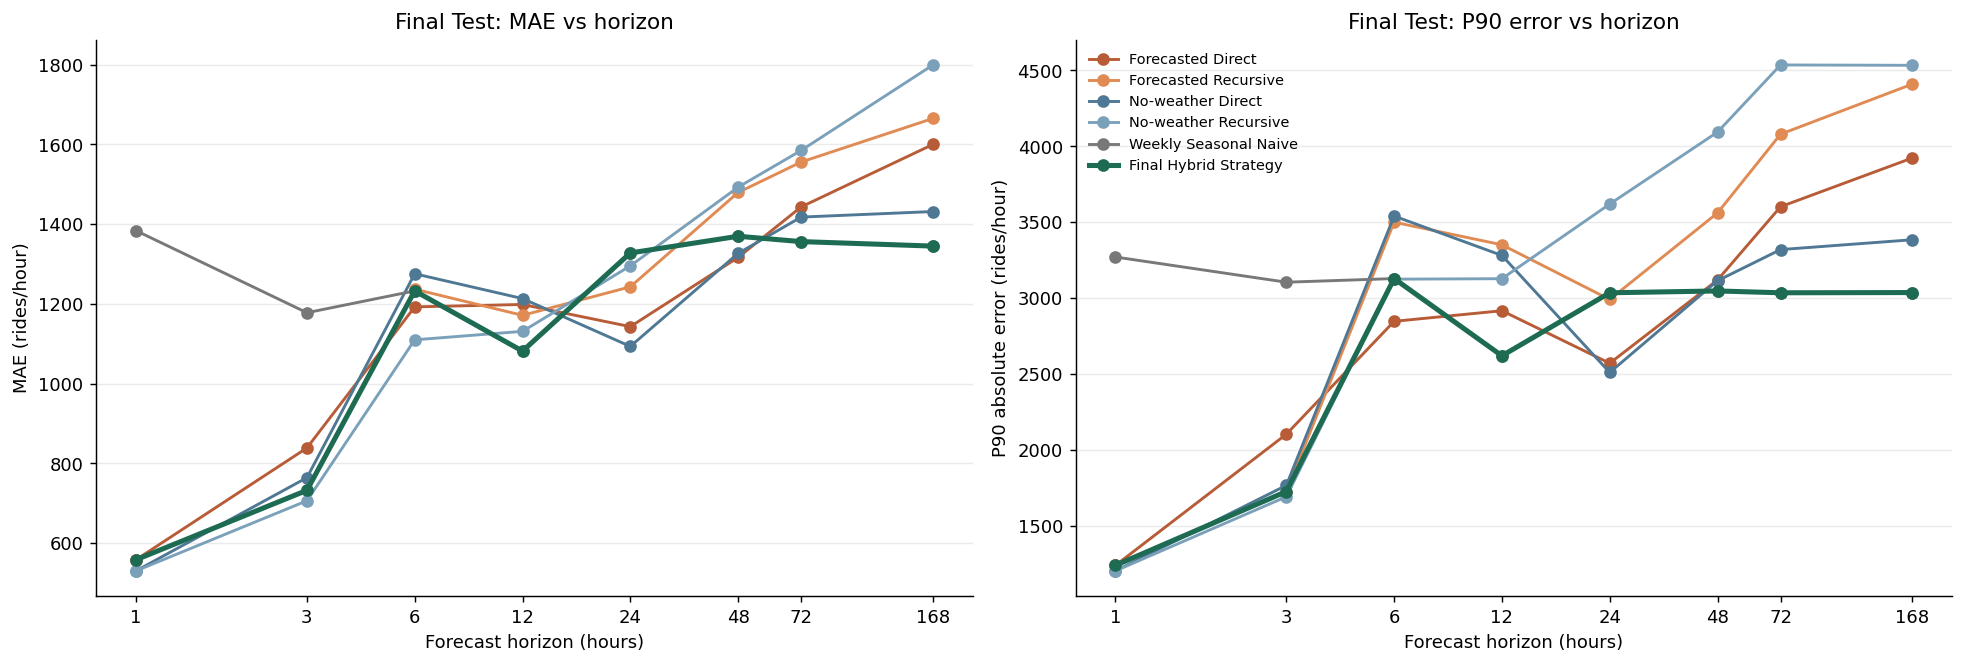

In [16]:
palette = {
    "Forecasted Direct": "#B85C38", "Forecasted Recursive": "#E08A54",
    "No-weather Direct": "#4E7894", "No-weather Recursive": "#7BA1BA",
    "Weekly Seasonal Naive": "#787878", "Final Hybrid Strategy": "#1E6B53",
}
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for method in EVALUATED_METHODS:
    frame = horizon_metrics.loc[horizon_metrics["Method"].eq(method)]
    for ax, column, label in (
        (axes[0], "MAE", "MAE (rides/hour)"),
        (axes[1], "P90 AE", "P90 absolute error (rides/hour)"),
    ):
        ax.plot(
            frame["Horizon"], frame[column], marker="o",
            linewidth=2.8 if method == "Final Hybrid Strategy" else 1.6,
            color=palette[method], label=method,
        )
for ax, title, ylabel in (
    (axes[0], "Final Test: MAE vs horizon", "MAE (rides/hour)"),
    (axes[1], "Final Test: P90 error vs horizon", "P90 absolute error (rides/hour)"),
):
    ax.set(title=title, xlabel="Forecast horizon (hours)", ylabel=ylabel)
    ax.set_xscale("log", base=2)
    ax.set_xticks(HORIZONS)
    ax.set_xticklabels([str(h) for h in HORIZONS])
    ax.grid(axis="y", alpha=0.25)
axes[1].legend(loc="upper left", fontsize=8, frameon=False)
display(fig)
plt.close(fig)

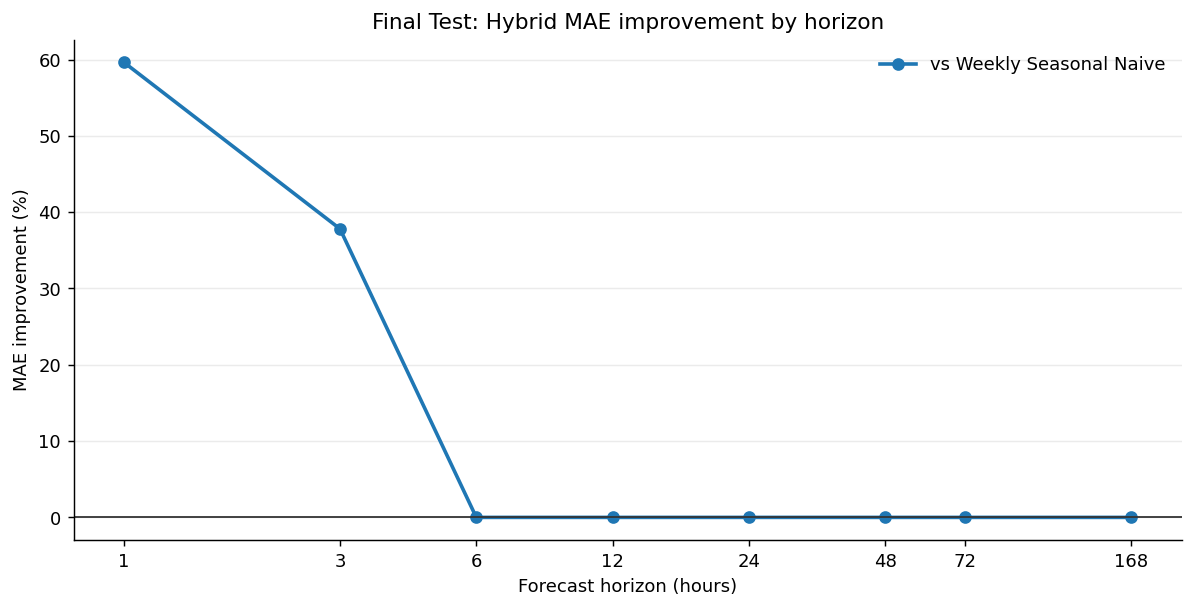

In [17]:
plot_gain = per_horizon_improvement.loc[
    per_horizon_improvement["Baseline"].isin(
        (locked_single_model, "Weekly Seasonal Naive")
    )
]
fig, ax = plt.subplots(figsize=(11, 5))
for method, frame in plot_gain.groupby("Baseline", sort=False):
    ax.plot(
        frame["Horizon"], frame["Improvement %"], marker="o", linewidth=2,
        label=f"vs {method}",
    )
ax.axhline(0, color="#333333", linewidth=1)
ax.set(
    title="Final Test: Hybrid MAE improvement by horizon",
    xlabel="Forecast horizon (hours)", ylabel="MAE improvement (%)",
)
ax.set_xscale("log", base=2)
ax.set_xticks(HORIZONS)
ax.set_xticklabels([str(h) for h in HORIZONS])
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
display(fig)
plt.close(fig)

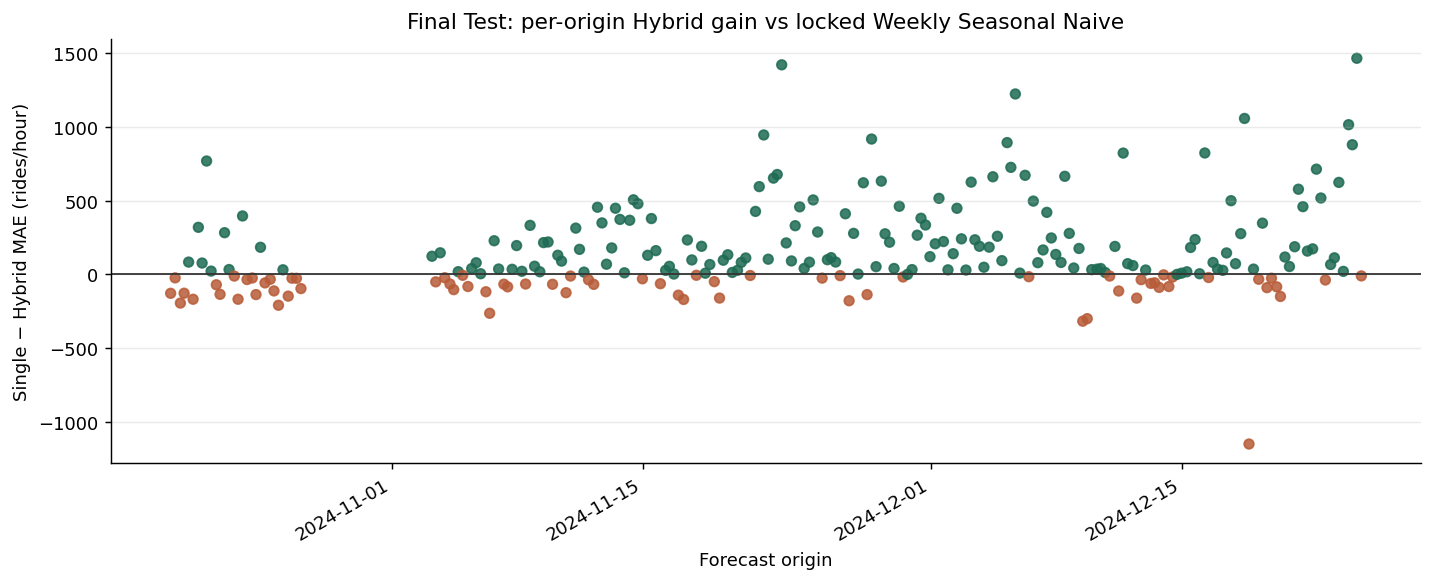

In [18]:
fig, ax = plt.subplots(figsize=(13, 4.8))
colors = np.where(origin_stability["Single minus hybrid MAE"] >= 0, "#1E6B53", "#B85C38")
ax.scatter(
    origin_stability["Forecast Origin"],
    origin_stability["Single minus hybrid MAE"],
    c=colors, s=28, alpha=0.85,
)
ax.axhline(0, color="#333333", linewidth=1)
ax.set(
    title=f"Final Test: per-origin Hybrid gain vs locked {locked_single_model}",
    xlabel="Forecast origin", ylabel="Single − Hybrid MAE (rides/hour)",
)
ax.grid(axis="y", alpha=0.25)
fig.autofmt_xdate()
display(fig)
plt.close(fig)

## Oracle Weather · 仅作研究上界参考

Oracle Direct/Recursive 在需求模型中读取目标真实天气，部署时不可获得。这两个模型沿用 Training-only HGB 参数和同一 Final Test origins/targets；它们的指标仅描述“知道未来真实天气”这一信息优势的参考范围，并非数学上保证误差最小的上界。Oracle 不在天气变量、路由、最佳单模型选择代码中。

In [19]:
oracle_columns = calendar_columns + list(WEATHER_COLUMNS) + list(DEMAND_COLUMNS)
def oracle_matrix(starts, targets):
    starts, targets = pd.DatetimeIndex(starts), pd.DatetimeIndex(targets)
    matrix = pd.concat([
        calendar_target.loc[targets].reset_index(drop=True),
        weather_target.loc[targets, list(WEATHER_COLUMNS)].reset_index(drop=True),
        origin_demand.loc[starts, list(DEMAND_COLUMNS)].reset_index(drop=True),
    ], axis=1)[oracle_columns]
    assert matrix.notna().all(axis=None)
    return matrix

oracle_models = {}
for horizon in HORIZONS:
    starts, targets = training_specs[horizon]
    fitted = HistGradientBoostingRegressor(**DEMAND_PARAMETERS)
    fitted.fit(
        oracle_matrix(starts, targets),
        observed_demand.reindex(targets).to_numpy(),
    )
    oracle_models[horizon] = fitted

def oracle_recursive_predict(starts):
    starts = pd.DatetimeIndex(starts)
    origins = starts - pd.Timedelta(hours=1)
    prediction = np.full((len(starts), 168), np.nan)
    for step in range(1, 169):
        targets = starts + pd.Timedelta(hours=step - 1)
        row = calendar_target.loc[targets].reset_index(drop=True).copy()
        row[list(WEATHER_COLUMNS)] = weather_target.loc[
            targets, list(WEATHER_COLUMNS)
        ].reset_index(drop=True)
        for lag in (1, 24, 168):
            if step <= lag:
                source = targets - pd.Timedelta(hours=lag)
                assert (source <= origins).all()
                row[f"lag_{lag}"] = observed_demand.reindex(source).to_numpy()
            else:
                row[f"lag_{lag}"] = prediction[:, step - lag - 1]
        for window in (3, 6):
            prior = []
            for back in range(1, window + 1):
                if step <= back:
                    source = targets - pd.Timedelta(hours=back)
                    assert (source <= origins).all()
                    prior.append(observed_demand.reindex(source).to_numpy())
                else:
                    prior.append(prediction[:, step - back - 1])
            row[f"rolling_mean_{window}"] = np.column_stack(prior).mean(axis=1)
        matrix = row[oracle_columns]
        prediction[:, step - 1] = oracle_models[1].predict(matrix)
    assert np.isfinite(prediction).all()
    return prediction

oracle_recursive_path = oracle_recursive_predict(test_starts)
for horizon in HORIZONS:
    mask = test_panel["Horizon"].eq(horizon)
    targets = test_starts + pd.Timedelta(hours=horizon - 1)
    test_panel.loc[mask, "Oracle Direct"] = oracle_models[horizon].predict(
        oracle_matrix(test_starts, targets)
    )
    test_panel.loc[mask, "Oracle Recursive"] = oracle_recursive_path[:, horizon - 1]
oracle_metric_rows = []
for horizon, frame in test_panel.groupby("Horizon", sort=True):
    for method in ("Oracle Direct", "Oracle Recursive"):
        oracle_metric_rows.append({
            "Horizon": horizon, "Method": method, "N": len(frame),
            **scores(frame["Actual"], frame[method]),
        })
oracle_horizon_metrics = pd.DataFrame(oracle_metric_rows)
oracle_summary = pd.DataFrame([
    {"Method": method, "N": len(test_panel), **scores(test_panel["Actual"], test_panel[method])}
    for method in ("Oracle Direct", "Oracle Recursive")
])
research_comparison = pd.concat([
    oracle_summary.assign(Status="research oracle"),
    summary_metrics.loc[
        summary_metrics["Method"].isin(
            ("Final Hybrid Strategy", "No-weather Direct",
             "No-weather Recursive", "Weekly Seasonal Naive")
        )
    ].assign(Status="deployable"),
], ignore_index=True).sort_values("MAE", kind="stable")
display(oracle_horizon_metrics.round(2))
display(research_comparison.round(2))

,Horizon,Method,N,MAE,RMSE,Median AE,P90 AE,Worst-decile MAE
0,1,Oracle Direct,238,508.97,766.75,331.92,1148.82,1797.78
1,1,Oracle Recursive,238,508.97,766.75,331.92,1148.82,1797.78
2,3,Oracle Direct,238,921.74,1227.04,715.49,1966.22,2692.63
3,3,Oracle Recursive,238,619.96,910.56,414.63,1482.62,2111.58
4,6,Oracle Direct,238,1235.31,1967.91,755.49,2725.97,4856.28
5,6,Oracle Recursive,238,897.82,1439.47,444.39,2218.61,3699.90
6,12,Oracle Direct,238,938.67,1303.29,633.07,2171.48,3076.46
7,12,Oracle Recursive,238,774.52,1230.30,397.17,1813.27,3131.21
8,24,Oracle Direct,238,836.68,1242.50,542.51,2036.25,3058.74
9,24,Oracle Recursive,238,897.62,1312.42,606.13,1896.67,3117.55


,Method,N,MAE,RMSE,Median AE,P90 AE,Worst-decile MAE,Status
1,Oracle Recursive,1904,833.04,1251.28,520.35,1984.53,3068.47,research oracle
0,Oracle Direct,1904,922.87,1377.04,604.91,2139.96,3308.53,research oracle
2,Final Hybrid Strategy,1904,1125.53,1821.07,629.29,2703.00,4411.08,deployable
3,No-weather Direct,1904,1131.71,1798.36,661.70,2683.47,4478.97,deployable
4,No-weather Recursive,1904,1206.32,2108.56,579.31,3094.32,5446.95,deployable
5,Weekly Seasonal Naive,1904,1284.35,1993.48,743.00,3051.00,4753.69,deployable


## Takeaways · Final Hybrid Strategy

下一个 Cell 打印由 Validation 锁定的最终映射，绝不依据 Test 重新选择。

**效果与稳定性**：Hybrid 在 Final Test 的汇总 MAE 为 1,125.53，五个固定 baseline 的汇总 MAE 都更高；但最接近的 No-weather Direct 为 1,131.71，差距仅 0.55%，且 Hybrid 的 RMSE（1,821.07 vs 1,798.36）与 P90（2,703.00 vs 2,683.47）略差。相比 Validation 锁定的最佳单模型 Weekly Naive，Hybrid 在 70.17% 的起报点更好；去掉收益最高的 10% 起报点后，平均收益仍为 82.55 rides/hour。工作日、周末、Peak、Off-peak 及三个目标月份相对 Weekly 均为正，但 10 月仅改善 1.09%。所以“稳定”只适用于相对 Weekly 的 MAE，不应扩展为所有指标和所有 baseline。

**Horizon 与天气**：相对 Weekly，最大收益在 1h（59.63%）和 3h（37.81%）。Validation 将 6–168h 都交给 Weekly；Final Test 上 Weekly 在 12h、72h、168h 仍是五个固定单模型中 MAE 最低，但 6h、24h、48h 有其他单模型更低，路由保持原样。Validation 的降水单变量得分 1,548.64，略好于 No-weather 1,571.91；Final Test 的 1h Forecasted Direct（558.52）不如 No-weather Direct（530.59），3h Forecasted Recursive（732.51）也不如 No-weather Recursive（706.35）。因此预测天气尚未证实值得作为生产依赖。Temperature-only 在 Validation 的得分 1,695.07，逊于降水、湿度、风的单变量，含全部天气的得分也差于无温度三变量；本次不支持“温度最有价值”。

**Oracle 与部署**：Oracle Recursive MAE 833.04，Hybrid 1,125.53，No-weather Direct 1,131.71，Weekly 1,284.35。真实未来天气具有研究信息价值，但目前可部署的预测天气没有在已选 1h/3h 恢复该优势。建议进入带监控的 shadow 工程验证，暂不直接生产部署；必须使用之后新增的时间段再验证。11 的 Test 未参与任何本次选择，然而它与 10 的旧测试区间重叠，且 Training 的月份编码存在季节外推限制。


In [20]:
final_strategy_table = route_table[["Horizon", "Selected strategy", "Weather inputs"]].copy()
display(Markdown("### Final Hybrid Strategy（只由 Validation 选择）"))
display(final_strategy_table)
print("Lock fingerprint:", lock_fingerprint)

summary_lookup = summary_metrics.set_index("Method")
hybrid_mae = summary_lookup.loc["Final Hybrid Strategy", "MAE"]
single_mae = summary_lookup.loc[locked_single_model, "MAE"]
beats_every_single = all(
    hybrid_mae < summary_lookup.loc[method, "MAE"] for method in DEPLOYABLE_COLUMNS
)
origin_stable = (
    origin_win_rate > 50
    and drop_top_gain > 0
    and leave_one_out_min > 0
)
stability_label = (
    "在此 holdout 上总体优于所有单模型，且起报点收益并非只由少数最大赢家支撑"
    if beats_every_single and origin_stable
    else "未达到总体优于所有单模型且起报点收益稳健的双重标准"
)
single_horizon_gain = per_horizon_improvement.loc[
    per_horizon_improvement["Baseline"].eq(locked_single_model)
].sort_values("Improvement %", ascending=False)
best_horizons = single_horizon_gain.head(3)[["Horizon", "Improvement %"]]
weekly_hard = [
    horizon for horizon in HORIZONS
    if locked_route[horizon] == "Weekly Seasonal Naive"
    or horizon_metrics.loc[
        horizon_metrics["Horizon"].eq(horizon)
        & horizon_metrics["Method"].eq("Weekly Seasonal Naive"), "MAE"
    ].iloc[0] <= horizon_metrics.loc[
        horizon_metrics["Horizon"].eq(horizon)
        & horizon_metrics["Method"].eq("Final Hybrid Strategy"), "MAE"
    ].iloc[0]
]
weather_route_horizons = [
    h for h in HORIZONS if locked_route[h].startswith("Forecasted")
]
selection_lookup = weather_choice_table.set_index("Weather input")["Selection MAE"]
temperature_only = selection_lookup.loc["Temperature"]
other_singletons = selection_lookup.loc[["Humidity", "Precipitation", "Wind"]]
temperature_best_singleton = temperature_only < other_singletons.min()
no_temp_combo = selection_lookup.loc["Humidity + precipitation + wind"]
all_four = selection_lookup.loc["All four"]

print(f"Final Test pooled Hybrid MAE: {hybrid_mae:.2f} rides/hour")
print(f"Locked best single model: {locked_single_model}; MAE: {single_mae:.2f}")
print("Hybrid 稳健性判断：", stability_label)
print("相对锁定单模型收益最大的 horizon：")
display(best_horizons.round(2))
print("Weekly Naive 被 Validation 路由选中或在 Final Test 不高于 Hybrid 的 horizon：", weekly_hard or "无")
print("Validation 选择了 Forecasted Weather 的 horizon：", weather_route_horizons or "无")
print(
    "Validation 最佳非空天气组合 vs No-weather selection MAE:",
    f"{selection_lookup.loc[selected_weather_variant]:.2f} vs {selection_lookup.loc['No-weather']:.2f}",
)
print(
    "温度检验：temperature-only 是否优于 humidity/precipitation/wind 单变量：",
    temperature_best_singleton,
    f"; full vs no-temperature trio MAE: {all_four:.2f} vs {no_temp_combo:.2f}",
)
print(
    "进入部署工程阶段：",
    "建议进入带监控的 shadow deployment / 工程验证"
    if beats_every_single and origin_stable
    else "暂不建议直接进入部署；先定位 holdout 失利或起报点不稳定原因，并另设未来时间窗验证",
)
print("研究纪律：Final Test 未参与变量、路由或比较器选择；Oracle 未参与选择。")

Lock fingerprint: 6f2460944230dfd5
Final Test pooled Hybrid MAE: 1125.53 rides/hour
Locked best single model: Weekly Seasonal Naive; MAE: 1284.35
Hybrid 稳健性判断： 在此 holdout 上总体优于所有单模型，且起报点收益并非只由少数最大赢家支撑
相对锁定单模型收益最大的 horizon：
Weekly Naive 被 Validation 路由选中或在 Final Test 不高于 Hybrid 的 horizon： [6, 12, 24, 48, 72, 168]
Validation 选择了 Forecasted Weather 的 horizon： [1, 3]
Validation 最佳非空天气组合 vs No-weather selection MAE: 1548.64 vs 1571.91
温度检验：temperature-only 是否优于 humidity/precipitation/wind 单变量： False ; full vs no-temperature trio MAE: 1660.41 vs 1602.53
进入部署工程阶段： 建议进入带监控的 shadow deployment / 工程验证
研究纪律：Final Test 未参与变量、路由或比较器选择；Oracle 未参与选择。


### Final Hybrid Strategy（只由 Validation 选择）

,Horizon,Selected strategy,Weather inputs
0,1,Forecasted Direct,precipitation
1,3,Forecasted Recursive,precipitation
2,6,Weekly Seasonal Naive,none
3,12,Weekly Seasonal Naive,none
4,24,Weekly Seasonal Naive,none
5,48,Weekly Seasonal Naive,none
6,72,Weekly Seasonal Naive,none
7,168,Weekly Seasonal Naive,none


,Horizon,Improvement %
4,1,59.63
9,3,37.81
14,6,0.00
